In [ ]:
content = """
# Problem Definition

Pneumonia is one of the most common and serious lung infections, and early diagnosis is critical for effective treatment.
Chest X-ray imaging is widely used in hospitals to detect signs of pneumonia. However, manual interpretation of X-ray
images can be time-consuming, prone to human error, and requires experienced radiologists.

This project aims to build a Deep Learning model using Convolutional Neural Networks (CNNs) to automatically classify
chest X-ray images into two categories:

- **Normal**
- **Pneumonia**

The goal is to develop an accurate and reliable AI system that can support medical professionals by providing fast
and automated pneumonia detection.

We use the *Chest X-Ray Images (Pneumonia)* dataset, which contains 5,863 X-ray images categorized into Normal and
Pneumonia across training, validation, and testing sets. The dataset includes pediatric chest X-rays that were
professionally graded and quality-checked by medical experts.

This project represents a real-world application of Deep Learning in the medical field and demonstrates how AI can
assist in disease detection and improve clinical decision-making.
"""
with open("Problem_Definition.md", "w") as f:
    f.write(content)


In [ ]:
from google.colab import files
files.download("Problem_Definition.md")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os

os.environ['KAGGLE_USERNAME'] = "radwahany2"
os.environ['KAGGLE_KEY'] = "KGAT_fafd92dfdc3d53da67eee0123a8bc175"


In [ ]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia


Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
chest-xray-pneumonia.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
import zipfile

with zipfile.ZipFile("chest-xray-pneumonia.zip", 'r') as zip_ref:
    zip_ref.extractall("chest_xray")


In [ ]:
import os

print(os.listdir("/content"))
print(os.listdir("/content/chest_xray"))


['.config', 'chest-xray-pneumonia.zip', 'Problem_Definition.md', 'chest_xray', 'sample_data']
['chest_xray']


In [ ]:
!find /content/chest_xray -maxdepth 3 -type d


/content/chest_xray
/content/chest_xray/chest_xray
/content/chest_xray/chest_xray/__MACOSX
/content/chest_xray/chest_xray/__MACOSX/chest_xray
/content/chest_xray/chest_xray/val
/content/chest_xray/chest_xray/val/PNEUMONIA
/content/chest_xray/chest_xray/val/NORMAL
/content/chest_xray/chest_xray/test
/content/chest_xray/chest_xray/test/PNEUMONIA
/content/chest_xray/chest_xray/test/NORMAL
/content/chest_xray/chest_xray/chest_xray
/content/chest_xray/chest_xray/chest_xray/val
/content/chest_xray/chest_xray/chest_xray/test
/content/chest_xray/chest_xray/chest_xray/train
/content/chest_xray/chest_xray/train
/content/chest_xray/chest_xray/train/PNEUMONIA
/content/chest_xray/chest_xray/train/NORMAL


In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
import os

data_dir = "/content/chest_xray/chest_xray"
splits = ["train", "val", "test"]
classes = ["NORMAL", "PNEUMONIA"]

total_images = 0

for split in splits:
    print(f"\n--- {split.upper()} ---")
    split_total = 0
    for cls in classes:
        cls_path = os.path.join(data_dir, split, cls)
        if os.path.exists(cls_path):
            count = len(os.listdir(cls_path))
            print(f"{cls}: {count} images")
            split_total += count
        else:
            print(f"Folder not found: {cls_path}")
    print(f"Total images in {split}: {split_total}")
    total_images += split_total

print(f"\nTotal images in dataset: {total_images}")



--- TRAIN ---
NORMAL: 1341 images
PNEUMONIA: 3875 images
Total images in train: 5216

--- VAL ---
NORMAL: 8 images
PNEUMONIA: 8 images
Total images in val: 16

--- TEST ---
NORMAL: 234 images
PNEUMONIA: 390 images
Total images in test: 624

Total images in dataset: 5856


In [ ]:
from PIL import Image
import os

data_dir = "/content/chest_xray/chest_xray"

for split in ["train", "val", "test"]:
    for cls in ["NORMAL", "PNEUMONIA"]:
        cls_path = os.path.join(data_dir, split, cls)
        if os.path.exists(cls_path):
            imgs = os.listdir(cls_path)[:10]
            for img_name in imgs:
                img_path = os.path.join(cls_path, img_name)
                try:
                    img = Image.open(img_path)
                    img.verify()
                except Exception as e:
                    print(f"Corrupt image: {img_path}, Error: {e}")
        else:
            print(f"Folder not found: {cls_path}")



In [ ]:
# Transforms مناسبة لـ ResNet18 (pretrained on ImageNet)
from torchvision import datasets, transforms

train_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),   # X-ray → 3 قنوات
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [ ]:
train_data = datasets.ImageFolder(os.path.join(data_dir, 'train'), transform=train_transforms)
val_data   = datasets.ImageFolder(os.path.join(data_dir, 'val'), transform=val_test_transforms)
test_data  = datasets.ImageFolder(os.path.join(data_dir, 'test'), transform=val_test_transforms)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_data, batch_size=32, shuffle=False)


Exploratory Data Analysis (EDA)

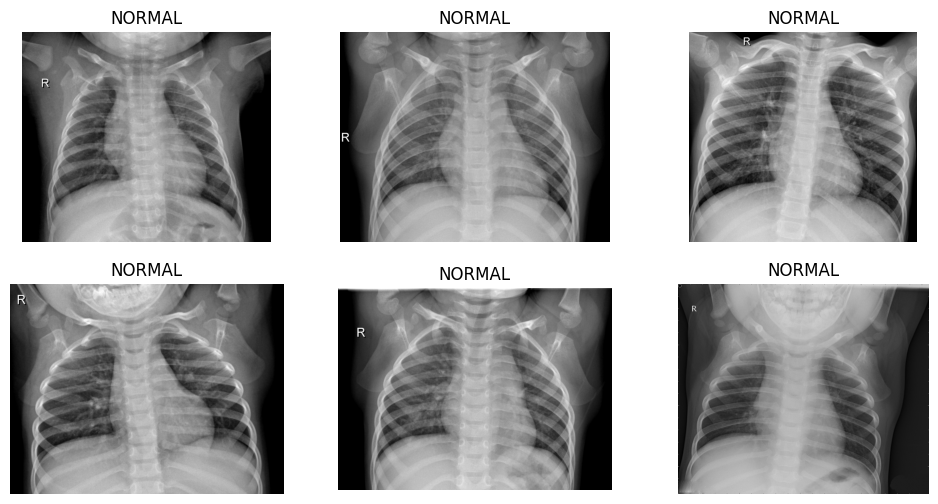

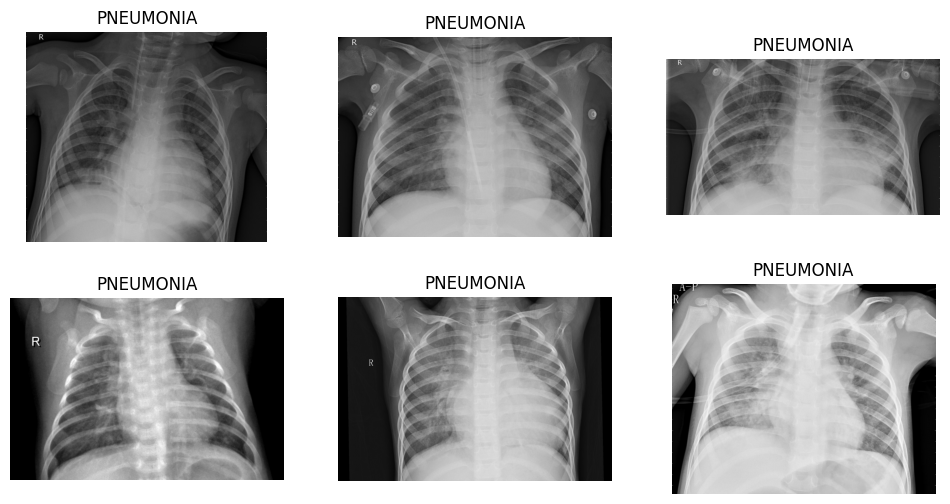

In [ ]:
def show_samples(category, split="train", n=6):
    path = os.path.join(data_dir, split, category)
    imgs = os.listdir(path)[:n]

    plt.figure(figsize=(12, 6))
    for i, img_name in enumerate(imgs):
        img_path = os.path.join(path, img_name)
        img = Image.open(img_path)

        plt.subplot(2, 3, i+1)
        plt.imshow(img, cmap="gray")
        plt.title(category)
        plt.axis("off")
    plt.show()

show_samples("NORMAL", split="train", n=6)
show_samples("PNEUMONIA", split="train", n=6)


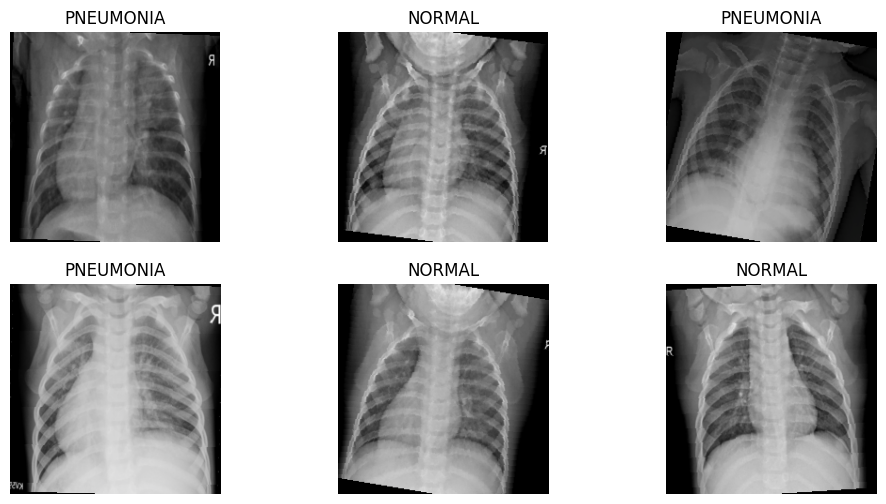

In [ ]:

imagenet_mean = np.array([0.485, 0.456, 0.406])
imagenet_std  = np.array([0.229, 0.224, 0.225])

def show_tensor_image(img_tensor):
    img = img_tensor.numpy().transpose(1, 2, 0)
    img = img * imagenet_std + imagenet_mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.axis('off')

data_iter = iter(train_loader)
images, labels = next(data_iter)

plt.figure(figsize=(12, 6))
for i in range(6):
    plt.subplot(2, 3, i+1)
    show_tensor_image(images[i])
    cls = train_data.classes[labels[i]]
    plt.title(cls)
plt.show()


Counter({1: 3875, 0: 1341})


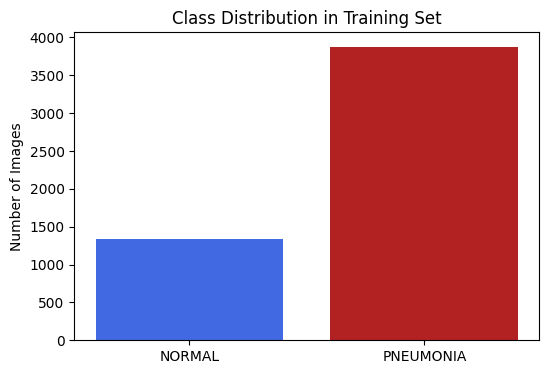

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt

labels = train_data.targets

count = Counter(labels)

print(count)


classes = train_data.classes
values = [count[0], count[1]]

plt.figure(figsize=(6,4))
plt.bar(classes, values, color=['royalblue', 'firebrick'])
plt.title("Class Distribution in Training Set")
plt.ylabel("Number of Images")
plt.show()


class Weights

In [ ]:
import torch
from collections import Counter


label_counts = Counter(train_data.targets)
print("Label Counts:", label_counts)

normal_count = label_counts[0]
pneumonia_count = label_counts[1]

total = normal_count + pneumonia_count


weight_normal = total / (2 * normal_count)
weight_pneumonia = total / (2 * pneumonia_count)

class_weights = torch.tensor([weight_normal, weight_pneumonia])

print("Class Weights:", class_weights)


Label Counts: Counter({1: 3875, 0: 1341})
Class Weights: tensor([1.9448, 0.6730])


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models


In [ ]:

model = models.resnet18(pretrained=True)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 199MB/s]


In [ ]:

for param in model.parameters():
    param.requires_grad = False


In [ ]:

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("Using device:", device)


Using device: cuda


In [ ]:

print(model.fc)
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print(f"Total parameters: {total_params}")
print(f"Trainable parameters: {trainable_params}")


Linear(in_features=512, out_features=2, bias=True)
Total parameters: 11177538
Trainable parameters: 1026
